# SimpleNN Testing

This notebook evaluates trained SimpleNN specialist models across different physical error rates.

---

## 🔴 Key Difference from GraphSAGE

| Aspect | SimpleNN (this notebook) | GraphSAGE |
|--------|--------------------------|----------|
| **Model per distance** | ✅ Yes (5 separate models) | ❌ No (1 model) |
| **Can test on new distances** | ❌ No (must train first) | ✅ Yes (extrapolation) |
| **Test distances** | 3, 5, 7, 9, 11 (trained on each) | 9, 11, 13 (unseen) |
| **Comparison type** | Specialist models | Generalist model |

**What we're comparing:**
- SimpleNN: Train a separate model for each distance → test on that same distance
- GraphSAGE: Train one model on d=3,5,7 → test on unseen d=9,11,13

This reveals the tradeoff: SimpleNN needs training data for every distance, but may achieve higher accuracy. GraphSAGE can extrapolate to new distances without retraining.

---

**Workflow:**
1. Load trained models for each distance
2. Evaluate on test data across different physical error rates
3. Compare with MWPM baseline
4. Generate comparison plots for GraphSAGE analysis

## Imports

In [1]:
import sys
import json
import random
import time
from pathlib import Path
from datetime import datetime

# Detect if running in Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/Research/QEC/quantum-error-correction/quantum-error-correction/code')
else:
    BASE_PATH = Path('../..')  # code/nn/training -> code/

sys.path.insert(0, str(BASE_PATH))

import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

# Import from benchmark_models.py
from benchmark_models import (
    SurfaceCodeSampler,
    SimpleNNModel,
    SimpleNN,
    FlatDatasetCache,
    ler_mwpm,
)

# Set up paths
TRAINING_DIR = BASE_PATH / "nn" / "training"
RESULTS_DIR = TRAINING_DIR / "results"
MODELS_DIR = TRAINING_DIR / "models"
PLOTS_DIR = TRAINING_DIR / "plots"

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

print(f"\nPaths:")
print(f"  BASE_PATH: {BASE_PATH}")
print(f"  MODELS_DIR: {MODELS_DIR}")
print(f"  RESULTS_DIR: {RESULTS_DIR}")
print(f"  PLOTS_DIR: {PLOTS_DIR}")

Using device: cuda
Using device: cuda
GPU: NVIDIA GeForce GTX 1080

Paths:
  BASE_PATH: ..\..
  MODELS_DIR: ..\..\nn\training\models
  RESULTS_DIR: ..\..\nn\training\results
  PLOTS_DIR: ..\..\nn\training\plots


## Configuration

In [2]:
# =============================================================================
# TESTING CONFIGURATION
# =============================================================================

# Distances to test (must have trained models)
TEST_DISTANCES = [3, 5, 7, 9, 11]

# Physical error rates for testing
P_VALUES = [0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008]

# Number of samples per distance per error rate
SAMPLES_PER_P = 10000

# Batch size for inference
BATCH_SIZE = 256

# Random seed
SEED = 42

print(f"Testing Configuration:")
print(f"  Distances: {TEST_DISTANCES}")
print(f"  P values: {P_VALUES}")
print(f"  Samples per p: {SAMPLES_PER_P:,}")
print(f"  Total samples per distance: {len(P_VALUES) * SAMPLES_PER_P:,}")

Testing Configuration:
  Distances: [3, 5, 7, 9, 11]
  P values: [0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008]
  Samples per p: 10,000
  Total samples per distance: 80,000


## Load Trained Models

In [3]:
# =============================================================================
# LOAD TRAINED MODELS
# =============================================================================

models = {}

print("Loading trained models...")
print()

for d in TEST_DISTANCES:
    model_path = MODELS_DIR / f"d{d}_specialist.pt"

    if not model_path.exists():
        print(f"  d={d}: Model not found at {model_path}")
        continue

    checkpoint = torch.load(model_path, map_location=device)

    # Reconstruct model
    num_detectors = checkpoint['num_detectors']
    hyperparams = checkpoint['hyperparams']

    model = SimpleNNModel(
        in_channels=num_detectors,
        hidden_dims=tuple(hyperparams['hidden_dims']),
        dropout=hyperparams['dropout']
    ).to(device)

    model.load_state_dict(checkpoint['state_dict'])
    model.eval()

    models[d] = {
        'model': model,
        'num_detectors': num_detectors,
        'hyperparams': hyperparams,
        'train_val_acc': checkpoint.get('val_accuracy', None),
        'train_test_acc': checkpoint.get('test_accuracy', None),
    }

    print(f"  d={d}: Loaded ({num_detectors} detectors, train_acc={checkpoint.get('test_accuracy', 0)*100:.2f}%)")

print(f"\nLoaded {len(models)} models: {list(models.keys())}")

Loading trained models...

  d=3: Loaded (24 detectors, train_acc=98.68%)
  d=5: Loaded (120 detectors, train_acc=96.73%)
  d=7: Loaded (336 detectors, train_acc=87.24%)
  d=9: Loaded (720 detectors, train_acc=64.98%)
  d=11: Loaded (1320 detectors, train_acc=39.62%)

Loaded 5 models: [3, 5, 7, 9, 11]


## Evaluate Models

In [4]:
# =============================================================================
# EVALUATE MODELS ACROSS ERROR RATES
# =============================================================================

def evaluate_at_p(model, d: int, p: float, n_samples: int):
    """Evaluate model accuracy at a specific error rate."""
    sampler = SurfaceCodeSampler(device=device)

    # Generate test data at this error rate
    detections, labels = sampler.sample(
        d=d,
        num_samples=n_samples,
        p_values=[p],
        p_weights=[1.0]
    )

    # Evaluate
    model.eval()
    correct = 0
    total = len(labels)

    with torch.no_grad():
        for i in range(0, total, BATCH_SIZE):
            X = detections[i:i+BATCH_SIZE]
            y = labels[i:i+BATCH_SIZE]
            pred = model(X)
            correct += ((pred.squeeze() > 0.5).float() == y).sum().item()

    return correct / total if total > 0 else 0.0


# Run evaluation
results = []

for d in tqdm(list(models.keys()), desc="Distances"):
    model_info = models[d]
    model = model_info['model']

    for p in tqdm(P_VALUES, desc=f"d={d} error rates", leave=False):
        accuracy = evaluate_at_p(model, d, p, SAMPLES_PER_P)

        results.append({
            'distance': d,
            'p': p,
            'accuracy': accuracy,
            'error_rate': 1 - accuracy,
            'n_samples': SAMPLES_PER_P,
        })

# Convert to DataFrame
df_results = pd.DataFrame(results)
print("\nEvaluation complete!")
print(df_results.pivot(index='p', columns='distance', values='accuracy').round(4))

Distances:   0%|          | 0/5 [00:00<?, ?it/s]

SurfaceCodeSampler initialized:
  Default error rate: 0.01
  Device: cuda
  Mode: Dynamic (supports any code distance)


SurfaceCodeSampler initialized:
  Default error rate: 0.01
  Device: cuda
  Mode: Dynamic (supports any code distance)
SurfaceCodeSampler initialized:
  Default error rate: 0.01
  Device: cuda
  Mode: Dynamic (supports any code distance)
SurfaceCodeSampler initialized:
  Default error rate: 0.01
  Device: cuda
  Mode: Dynamic (supports any code distance)
SurfaceCodeSampler initialized:
  Default error rate: 0.01
  Device: cuda
  Mode: Dynamic (supports any code distance)
SurfaceCodeSampler initialized:
  Default error rate: 0.01
  Device: cuda
  Mode: Dynamic (supports any code distance)


Distances:  20%|██        | 1/5 [00:00<00:03,  1.23it/s]

SurfaceCodeSampler initialized:
  Default error rate: 0.01
  Device: cuda
  Mode: Dynamic (supports any code distance)
SurfaceCodeSampler initialized:
  Default error rate: 0.01
  Device: cuda
  Mode: Dynamic (supports any code distance)


...

SurfaceCodeSampler initialized:
  Default error rate: 0.01
  Device: cuda
  Mode: Dynamic (supports any code distance)


SurfaceCodeSampler initialized:
  Default error rate: 0.01
  Device: cuda
  Mode: Dynamic (supports any code distance)


SurfaceCodeSampler initialized:
  Default error rate: 0.01
  Device: cuda
  Mode: Dynamic (supports any code distance)


Distances: 100%|██████████| 5/5 [00:05<00:00,  1.16s/it]


Evaluation complete!
distance      3       5       7       9       11
p                                               
0.001     0.9989  0.9996  0.9948  0.8421  0.2173
0.002     0.9973  0.9961  0.9720  0.7283  0.3383
0.003     0.9932  0.9889  0.9363  0.6583  0.4124
0.004     0.9895  0.9784  0.8853  0.6030  0.4474
0.005     0.9818  0.9622  0.8341  0.5727  0.4772
0.006     0.9771  0.9426  0.7813  0.5526  0.4759
0.007     0.9699  0.9109  0.7212  0.5302  0.4828
0.008     0.9592  0.8858  0.6833  0.5212  0.5036


In [5]:
# =============================================================================
# COMPUTE MWPM BASELINE
# =============================================================================

print("Computing MWPM baseline...")

mwpm_results = []

for d in tqdm(list(models.keys()), desc="MWPM distances"):
    for p in P_VALUES:
        ler = ler_mwpm(p, d, num_shots=SAMPLES_PER_P)
        mwpm_results.append({
            'distance': d,
            'p': p,
            'ler': ler,
            'accuracy': 1 - ler,
        })

df_mwpm = pd.DataFrame(mwpm_results)
print("\nMWPM Logical Error Rates:")
print(df_mwpm.pivot(index='p', columns='distance', values='ler').round(4))

Computing MWPM baseline...


MWPM distances: 100%|██████████| 5/5 [00:15<00:00,  3.05s/it]


MWPM Logical Error Rates:
distance      3       5       7       9       11
p                                               
0.001     0.0013  0.0002  0.0000  0.0000  0.0000
0.002     0.0032  0.0005  0.0003  0.0000  0.0000
0.003     0.0049  0.0030  0.0009  0.0006  0.0002
0.004     0.0126  0.0079  0.0042  0.0023  0.0014
0.005     0.0189  0.0141  0.0099  0.0072  0.0049
0.006     0.0221  0.0222  0.0186  0.0150  0.0127
0.007     0.0324  0.0356  0.0315  0.0305  0.0290
0.008     0.0403  0.0529  0.0534  0.0545  0.0536


## Save Results

In [6]:
# =============================================================================
# SAVE EVALUATION RESULTS
# =============================================================================

# Combine SimpleNN and MWPM results
df_combined = df_results.merge(
    df_mwpm[['distance', 'p', 'ler', 'accuracy']].rename(
        columns={'ler': 'mwpm_ler', 'accuracy': 'mwpm_accuracy'}
    ),
    on=['distance', 'p'],
    how='left'
)

# Calculate improvement over MWPM
df_combined['improvement_over_mwpm'] = (
    (df_combined['accuracy'] - df_combined['mwpm_accuracy']) / df_combined['mwpm_accuracy'] * 100
)

# Save to CSV
csv_path = RESULTS_DIR / "evaluation_results.csv"
df_combined.to_csv(csv_path, index=False)
print(f"Results saved to: {csv_path}")

# Save to JSON for programmatic access
json_path = RESULTS_DIR / "evaluation_results.json"
df_combined.to_json(json_path, orient='records', indent=2)
print(f"Results saved to: {json_path}")

# Display summary
print("\nSimpleNN vs MWPM Accuracy:")
print(df_combined.pivot(index='p', columns='distance', values='accuracy').round(4))

Results saved to: ..\..\nn\training\results\evaluation_results.csv
Results saved to: ..\..\nn\training\results\evaluation_results.json

SimpleNN vs MWPM Accuracy:
distance      3       5       7       9       11
p                                               
0.001     0.9989  0.9996  0.9948  0.8421  0.2173
0.002     0.9973  0.9961  0.9720  0.7283  0.3383
0.003     0.9932  0.9889  0.9363  0.6583  0.4124
0.004     0.9895  0.9784  0.8853  0.6030  0.4474
0.005     0.9818  0.9622  0.8341  0.5727  0.4772
0.006     0.9771  0.9426  0.7813  0.5526  0.4759
0.007     0.9699  0.9109  0.7212  0.5302  0.4828
0.008     0.9592  0.8858  0.6833  0.5212  0.5036


## Visualization

Plot saved to: ..\..\nn\training\plots\evaluation_results.png


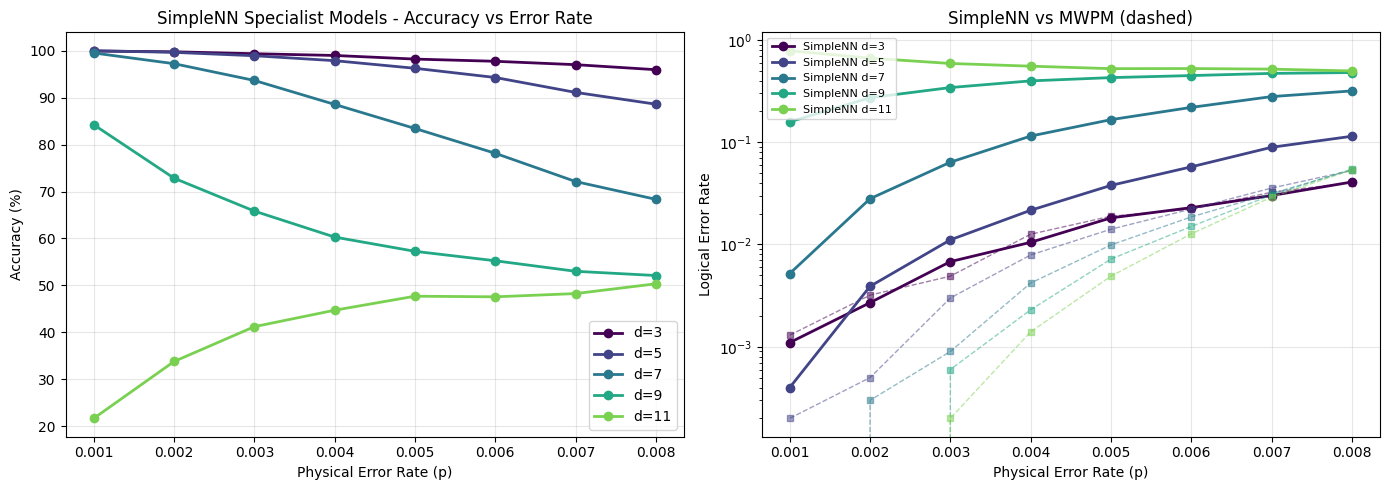

In [7]:
# =============================================================================
# PLOT: ACCURACY VS ERROR RATE
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.viridis(np.linspace(0, 0.8, len(models)))

# Plot 1: SimpleNN accuracy
ax1 = axes[0]
for i, d in enumerate(sorted(models.keys())):
    df_d = df_results[df_results['distance'] == d]
    ax1.plot(df_d['p'], df_d['accuracy'] * 100, 'o-', color=colors[i],
             label=f'd={d}', markersize=6, linewidth=2)

ax1.set_xlabel('Physical Error Rate (p)')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('SimpleNN Specialist Models - Accuracy vs Error Rate')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Comparison with MWPM (error rates)
ax2 = axes[1]
for i, d in enumerate(sorted(models.keys())):
    # SimpleNN
    df_d = df_results[df_results['distance'] == d]
    ax2.plot(df_d['p'], df_d['error_rate'], 'o-', color=colors[i],
             label=f'SimpleNN d={d}', markersize=6, linewidth=2)

    # MWPM
    df_mwpm_d = df_mwpm[df_mwpm['distance'] == d]
    ax2.plot(df_mwpm_d['p'], df_mwpm_d['ler'], 's--', color=colors[i],
             alpha=0.5, markersize=4, linewidth=1)

ax2.set_xlabel('Physical Error Rate (p)')
ax2.set_ylabel('Logical Error Rate')
ax2.set_title('SimpleNN vs MWPM (dashed)')
ax2.set_yscale('log')
ax2.legend(loc='upper left', fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()

# Save plot
plot_path = PLOTS_DIR / "evaluation_results.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"Plot saved to: {plot_path}")

plt.show()

Plot saved to: ..\..\nn\training\plots\comparison_p0.005.png


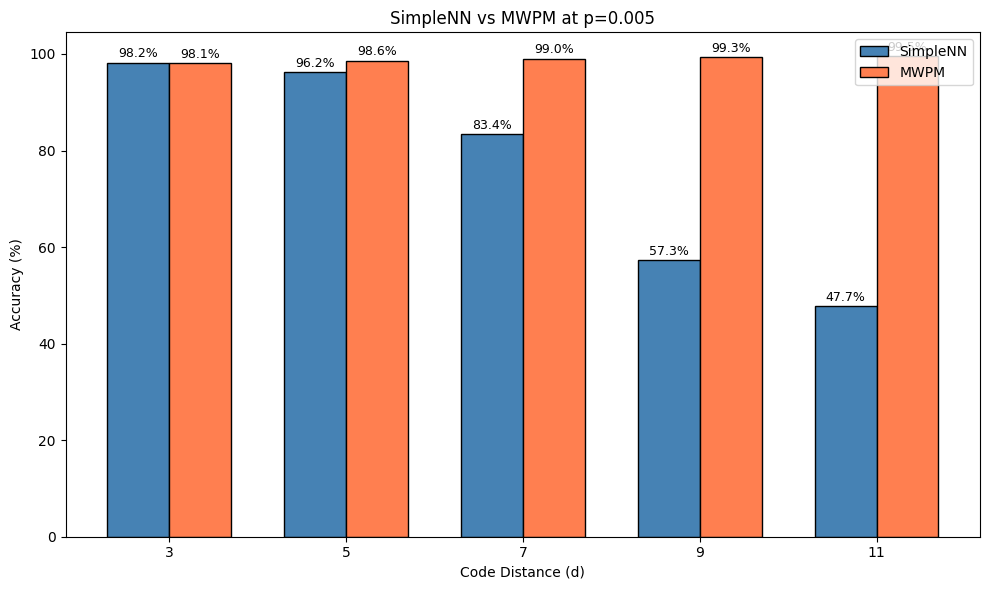

In [8]:
# =============================================================================
# PLOT: BAR CHART COMPARISON AT FIXED ERROR RATE
# =============================================================================

# Pick a representative error rate
p_fixed = 0.005

fig, ax = plt.subplots(figsize=(10, 6))

# Get data for this error rate
df_fixed = df_combined[df_combined['p'] == p_fixed].sort_values('distance')

x = np.arange(len(df_fixed))
width = 0.35

bars1 = ax.bar(x - width/2, df_fixed['accuracy'] * 100, width,
               label='SimpleNN', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, df_fixed['mwpm_accuracy'] * 100, width,
               label='MWPM', color='coral', edgecolor='black')

ax.set_xlabel('Code Distance (d)')
ax.set_ylabel('Accuracy (%)')
ax.set_title(f'SimpleNN vs MWPM at p={p_fixed}')
ax.set_xticks(x)
ax.set_xticklabels(df_fixed['distance'].values)
ax.legend()

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()

# Save plot
plot_path = PLOTS_DIR / f"comparison_p{p_fixed}.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"Plot saved to: {plot_path}")

plt.show()

## Summary Statistics

In [9]:
# =============================================================================
# SUMMARY STATISTICS
# =============================================================================

print("="*60)
print("SIMPLENN SPECIALIST MODELS - SUMMARY")
print("="*60)

# Average accuracy per distance
avg_by_dist = df_combined.groupby('distance').agg({
    'accuracy': 'mean',
    'mwpm_accuracy': 'mean',
    'improvement_over_mwpm': 'mean'
}).round(4)

print("\nAverage Performance by Distance:")
print(avg_by_dist.rename(columns={
    'accuracy': 'SimpleNN Acc',
    'mwpm_accuracy': 'MWPM Acc',
    'improvement_over_mwpm': 'Improvement (%)'
}))

# Best and worst cases
print("\n" + "-"*60)
best_case = df_combined.loc[df_combined['accuracy'].idxmax()]
worst_case = df_combined.loc[df_combined['accuracy'].idxmin()]

print(f"Best accuracy: {best_case['accuracy']*100:.2f}% (d={int(best_case['distance'])}, p={best_case['p']})")
print(f"Worst accuracy: {worst_case['accuracy']*100:.2f}% (d={int(worst_case['distance'])}, p={worst_case['p']})")

# Export summary for comparison with GraphSAGE
summary = {
    'model_type': 'SimpleNN',
    'strategy': 'specialist (one model per distance)',
    'distances_trained': list(models.keys()),
    'avg_accuracy_by_distance': avg_by_dist['accuracy'].to_dict(),
    'comparison_note': 'Each model trained on 1M samples for 50 epochs using best hyperparameters from tuning',
}

summary_path = RESULTS_DIR / "summary_for_comparison.json"
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f"\nSummary exported to: {summary_path}")

SIMPLENN SPECIALIST MODELS - SUMMARY

Average Performance by Distance:
          SimpleNN Acc  MWPM Acc  Improvement (%)
distance                                         
3               0.9834    0.9830           0.0334
5               0.9581    0.9830          -2.5722
7               0.8510    0.9852         -13.7710
9               0.6260    0.9862         -36.6315
11              0.4194    0.9873         -57.4122

------------------------------------------------------------
Best accuracy: 99.96% (d=5, p=0.001)
Worst accuracy: 21.73% (d=11, p=0.001)

Summary exported to: ..\..\nn\training\results\summary_for_comparison.json
